# Climate Trend and ENSO Correlation at Base Aérea Marco Fidel Suárez, Cali (2007–2024)

**Objective:** Answer three linked questions using long-term IDEAM daily temperature data and ENSO indices:

1. **Is Cali warming?** Trend test on annual mean T_min, T_max, T_mean.
2. **Are extremes changing?** Trend test on annual counts of hot days and warm nights.
3. **Does ENSO modulate temperature?** Correlation between annual temperature metrics and the annual mean MEI/ONI index.

**Station:** Base Aérea Marco Fidel Suárez (code 26085170), Cali, 971 m elevation.
**Data:** IDEAM 2007–2024, ENSO index from NOAA (MEI v2 primary, ONI fallback).

## Section 1 — Setup and Load

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import urllib.request

In [13]:
# Load IDEAM consolidated daily CSV
current = Path.cwd()
while current != current.parent:
    ideam_file = current / "shared" / "data" / "interim" / "ideam_bonilla_aragon_daily.csv"
    if ideam_file.exists():
        IDEAM_FILE = ideam_file
        break
    current = current.parent
else:
    raise FileNotFoundError("ideam_bonilla_aragon_daily.csv not found")

df_raw = pd.read_csv(IDEAM_FILE, parse_dates=['fecha'], index_col='fecha')
df_raw = df_raw.sort_index()

print(f"✓ Loaded IDEAM daily table: {len(df_raw)} records")
print(f"  Date range: {df_raw.index.min()} to {df_raw.index.max()}")

✓ Loaded IDEAM daily table: 6596 records
  Date range: 2006-11-23 00:00:00 to 2024-12-13 00:00:00


In [14]:
# Apply quality filter (standard from notebooks 07–08)
print(f"\n{'='*80}")
print("QUALITY FILTER")
print(f"{'='*80}")

mask_hourly = (df_raw['hourly_count'] >= 18) if 'hourly_count' in df_raw.columns else pd.Series([True] * len(df_raw), index=df_raw.index)
mask_min_max = df_raw['t_min'] <= df_raw['t_max']
mask_range = (df_raw['t_max'] - df_raw['t_min']) <= 20
mask_extreme_min = df_raw['t_min'] >= 10
mask_extreme_max = df_raw['t_max'] <= 40

mask_valid = mask_hourly & mask_min_max & mask_range & mask_extreme_min & mask_extreme_max
df = df_raw[mask_valid].copy()

print(f"\nInitial records:  {len(df_raw)}")
print(f"Valid records:    {len(df)} ({len(df)/len(df_raw)*100:.1f}%)")
print(f"Retained for analysis: {df.index.min()} to {df.index.max()}")


QUALITY FILTER

Initial records:  6596
Valid records:    3839 (58.2%)
Retained for analysis: 2006-11-24 00:00:00 to 2024-12-12 00:00:00


## Section 2 — Retained-Years Selection

In [15]:
# Apply 60% coverage threshold per year
print(f"\n{'='*80}")
print("YEARLY COVERAGE")
print(f"{'='*80}")

df['year'] = df.index.year

yearly_stats = []
for year in sorted(df['year'].unique()):
    year_data = df[df['year'] == year]
    days_in_year = 366 if year % 4 == 0 and (year % 100 != 0 or year % 400 == 0) else 365
    actual_days = len(year_data)
    coverage_pct = (actual_days / days_in_year) * 100
    yearly_stats.append({
        'Year': year,
        'Valid_days': actual_days,
        'Expected_days': days_in_year,
        'Coverage_%': f"{coverage_pct:.1f}%",
        'Retained': 'Yes' if coverage_pct >= 60 else 'No'
    })

df_yearly = pd.DataFrame(yearly_stats)
print(f"\n{df_yearly.to_string(index=False)}")

retained_years = [y for y in df_yearly['Year'].values if df_yearly[df_yearly['Year'] == y]['Retained'].values[0] == 'Yes']
excluded_years = [y for y in df_yearly['Year'].values if df_yearly[df_yearly['Year'] == y]['Retained'].values[0] == 'No']

print(f"\nRetained years ({len(retained_years)}): {retained_years}")
if excluded_years:
    print(f"Excluded years ({len(excluded_years)}): {excluded_years}")

if len(retained_years) < 8:
    raise ValueError(f"Insufficient retained years ({len(retained_years)} < 8 minimum for trend analysis)")

df_analysis = df[df['year'].isin(retained_years)].copy()


YEARLY COVERAGE

 Year  Valid_days  Expected_days Coverage_% Retained
 2006          32            365       8.8%       No
 2007         339            365      92.9%      Yes
 2008         331            366      90.4%      Yes
 2009         313            365      85.8%      Yes
 2010         331            365      90.7%      Yes
 2011         230            365      63.0%      Yes
 2012         172            366      47.0%       No
 2013         329            365      90.1%      Yes
 2014         269            365      73.7%      Yes
 2015         247            365      67.7%      Yes
 2016         259            366      70.8%      Yes
 2017         335            365      91.8%      Yes
 2018         158            365      43.3%       No
 2019         283            365      77.5%      Yes
 2020          83            366      22.7%       No
 2024         128            366      35.0%       No

Retained years (11): [np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2

## Section 3 — Annual Aggregates

In [16]:
# Compute percentiles for extreme counts (from full valid record)
print(f"\n{'='*80}")
print("EXTREME PERCENTILES (from full valid record)")
print(f"{'='*80}")

pct_95_t_max = df['t_max'].quantile(0.95)
pct_95_t_min = df['t_min'].quantile(0.95)

print(f"\n95th percentile T_max: {pct_95_t_max:.2f}°C")
print(f"95th percentile T_min: {pct_95_t_min:.2f}°C")

# Build annual DataFrame
print(f"\n{'='*80}")
print("ANNUAL AGGREGATES")
print(f"{'='*80}\n")

annual_records = []
for year in sorted(retained_years):
    year_data = df_analysis[df_analysis['year'] == year]
    
    annual_records.append({
        'year': year,
        'mean_t_max': year_data['t_max'].mean(),
        'mean_t_min': year_data['t_min'].mean(),
        'mean_t_mean': year_data['t_mean'].mean(),
        'hot_days': (year_data['t_max'] > pct_95_t_max).sum(),
        'warm_nights': (year_data['t_min'] > pct_95_t_min).sum(),
        'valid_days': len(year_data),
    })

df_annual = pd.DataFrame(annual_records).set_index('year')
print(df_annual.to_string())


EXTREME PERCENTILES (from full valid record)

95th percentile T_max: 33.50°C
95th percentile T_min: 22.40°C

ANNUAL AGGREGATES

      mean_t_max  mean_t_min  mean_t_mean  hot_days  warm_nights  valid_days
year                                                                        
2007   30.023009   20.346608    24.504397         5            4         339
2008   29.063142   19.963142    23.789231         0            1         331
2009   30.926837   20.831310    25.150991        21           15         313
2010   30.258006   20.668278    24.721254        13           29         331
2011   30.099130   20.171739    24.263635         5            3         230
2013   30.482371   20.667477    24.895025         9           11         329
2014   30.414870   20.538662    24.826610        12            2         269
2015   31.563563   21.157490    25.697752        36           26         247
2016   30.838224   21.282625    25.341400        18           49         259
2017   30.411642   20.35

## Section 4 — Trend Test: Annual Mean Temperatures


TEMPERATURE TRENDS (Mann-Kendall + Sen's slope)



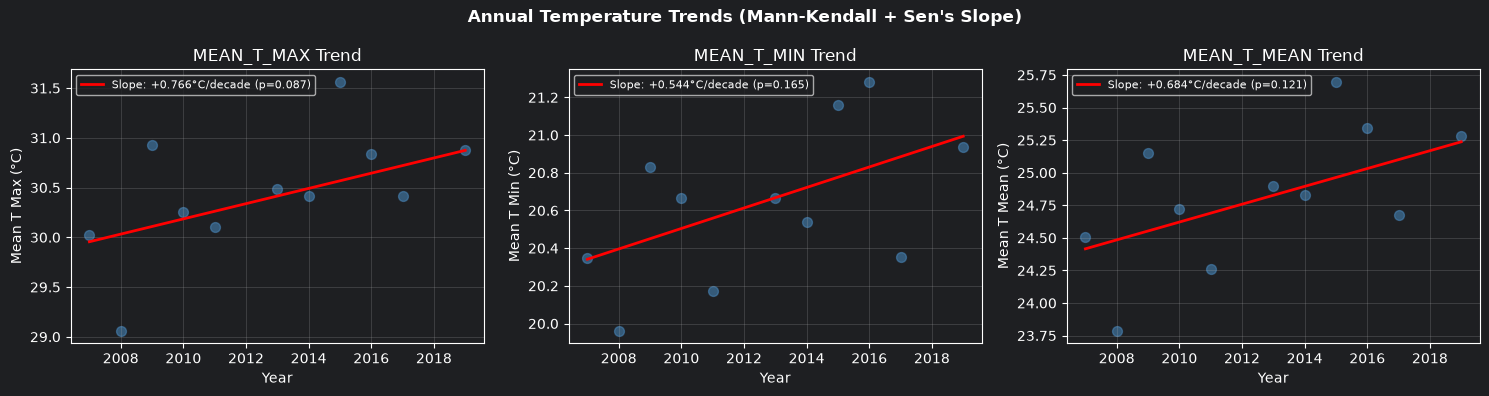

   Variable Slope (°C/decade) p-value Significant (α=0.05)          95% CI
 MEAN_T_MAX            +0.766  0.0866                   No [-0.049, 1.926]
 MEAN_T_MIN            +0.544  0.1646                   No [-0.437, 1.251]
MEAN_T_MEAN            +0.684  0.1210                   No [-0.508, 1.877]


In [17]:
# Mann-Kendall + Sen's slope for temperature trends
from scipy.stats import theilslopes

print(f"\n{'='*80}")
print("TEMPERATURE TRENDS (Mann-Kendall + Sen's slope)")
print(f"{'='*80}\n")

trend_results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, var in enumerate(['mean_t_max', 'mean_t_min', 'mean_t_mean']):
    years = df_annual.index.values
    values = df_annual[var].values
    
    # Mann-Kendall (using Kendall's tau)
    tau, p_value = stats.kendalltau(years, values)
    
    # Sen's slope with 95% CI
    slope, intercept, low_ci, high_ci = theilslopes(values, years, alpha=0.05)
    
    # Convert slope to °C/decade
    slope_decade = slope * 10
    low_ci_decade = low_ci * 10
    high_ci_decade = high_ci * 10
    
    trend_results.append({
        'Variable': var.upper(),
        'Slope (°C/decade)': f"{slope_decade:+.3f}",
        'p-value': f"{p_value:.4f}",
        'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
        '95% CI': f"[{low_ci_decade:.3f}, {high_ci_decade:.3f}]",
    })
    
    # Plot
    ax = axes[idx]
    ax.scatter(years, values, s=50, alpha=0.6, color='steelblue')
    fit_line = intercept + slope * years
    ax.plot(years, fit_line, 'r-', linewidth=2, label=f'Slope: {slope_decade:+.3f}°C/decade (p={p_value:.3f})')
    ax.set_xlabel('Year')
    ax.set_ylabel(var.replace('_', ' ').title() + ' (°C)')
    ax.set_title(f'{var.upper()} Trend')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Annual Temperature Trends (Mann-Kendall + Sen\'s Slope)', fontweight='bold')
plt.tight_layout()
plt.show()

df_trends = pd.DataFrame(trend_results)
print(df_trends.to_string(index=False))

**Interpretation:**

## Section 5 — Trend Test: Annual Extreme Counts


EXTREME TRENDS (Mann-Kendall + Sen's slope)



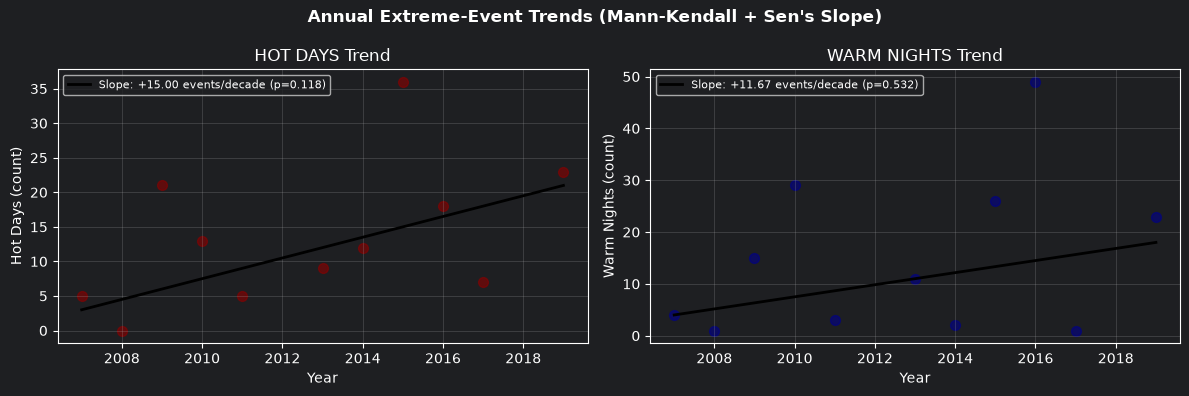

   Variable Slope (events/decade) p-value Significant (α=0.05)         95% CI
   HOT_DAYS                +15.00  0.1183                   No [-5.00, 26.00]
WARM_NIGHTS                +11.67  0.5322                   No [-7.50, 50.00]


In [18]:
print(f"\n{'='*80}")
print("EXTREME TRENDS (Mann-Kendall + Sen's slope)")
print(f"{'='*80}\n")

extreme_trends = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for idx, var in enumerate(['hot_days', 'warm_nights']):
    years = df_annual.index.values
    values = df_annual[var].values
    
    # Mann-Kendall
    tau, p_value = stats.kendalltau(years, values)
    
    # Sen's slope
    slope, intercept, low_ci, high_ci = theilslopes(values, years, alpha=0.05)
    
    # Convert to events/decade
    slope_decade = slope * 10
    low_ci_decade = low_ci * 10
    high_ci_decade = high_ci * 10
    
    extreme_trends.append({
        'Variable': var.upper(),
        'Slope (events/decade)': f"{slope_decade:+.2f}",
        'p-value': f"{p_value:.4f}",
        'Significant (α=0.05)': 'Yes' if p_value < 0.05 else 'No',
        '95% CI': f"[{low_ci_decade:.2f}, {high_ci_decade:.2f}]",
    })
    
    # Plot
    ax = axes[idx]
    ax.scatter(years, values, s=50, alpha=0.6, color='darkred' if var == 'hot_days' else 'darkblue')
    fit_line = intercept + slope * years
    ax.plot(years, fit_line, 'k-', linewidth=2, label=f'Slope: {slope_decade:+.2f} events/decade (p={p_value:.3f})')
    ax.set_xlabel('Year')
    ax.set_ylabel(var.replace('_', ' ').title() + ' (count)')
    ax.set_title(f'{var.replace("_", " ").upper()} Trend')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Annual Extreme-Event Trends (Mann-Kendall + Sen\'s Slope)', fontweight='bold')
plt.tight_layout()
plt.show()

df_extremes = pd.DataFrame(extreme_trends)
print(df_extremes.to_string(index=False))

**Interpretation:**

## Section 6 — Load ENSO Index

In [19]:
print(f"\n{'='*80}")
print("ENSO INDEX DOWNLOAD")
print(f"{'='*80}\n")

enso_index_used = None
meiv2_url = "https://psl.noaa.gov/enso/mei/data/meiv2.data"
oni_url = "https://psl.noaa.gov/data/correlation/oni.data"

# Try MEI v2 first
try:
    print("Attempting MEI v2 download...")
    response = urllib.request.urlopen(meiv2_url, timeout=10)
    meiv2_text = response.read().decode('utf-8')
    enso_index_used = "MEI v2"
    print("✓ MEI v2 downloaded successfully")
except Exception as e:
    print(f"⚠ MEI v2 download failed: {str(e)[:60]}")
    print("Attempting ONI fallback...")
    try:
        response = urllib.request.urlopen(oni_url, timeout=10)
        meiv2_text = response.read().decode('utf-8')
        enso_index_used = "ONI"
        print("✓ ONI downloaded successfully")
    except Exception as e2:
        raise RuntimeError(f"Both ENSO downloads failed. MEI: {str(e)[:40]}, ONI: {str(e2)[:40]}")

print(f"Using ENSO index: {enso_index_used}")


ENSO INDEX DOWNLOAD

Attempting MEI v2 download...
✓ MEI v2 downloaded successfully
Using ENSO index: MEI v2


In [20]:
# Parse ENSO index
print(f"\nParsing {enso_index_used} data...")

enso_monthly = {}
for line in meiv2_text.split('\n'):
    line = line.strip()
    if not line or line.startswith('Year'):
        continue
    parts = line.split()
    if len(parts) >= 2:
        try:
            year = int(parts[0])
            # Extract monthly values
            for i, val_str in enumerate(parts[1:13]):  # 12 months
                try:
                    val = float(val_str)
                    if val > -999:  # Skip missing values
                        enso_monthly[(year, i+1)] = val
                except ValueError:
                    pass
        except ValueError:
            pass

# Compute annual means
enso_annual = {}
for year in sorted(retained_years):
    monthly_vals = [enso_monthly.get((year, m)) for m in range(1, 13)]
    valid_vals = [v for v in monthly_vals if v is not None]
    if valid_vals:
        enso_annual[year] = np.mean(valid_vals)

df_annual['enso_index'] = pd.Series(enso_annual)

print(f"\n✓ Annual {enso_index_used} means:")
print(df_annual[['enso_index']].to_string())


Parsing MEI v2 data...

✓ Annual MEI v2 means:
      enso_index
year            
2007   -0.573333
2008   -1.052500
2009   -0.025000
2010   -0.871667
2011   -1.277500
2013   -0.385833
2014    0.005000
2015    1.299167
2016    0.458333
2017   -0.471667
2019    0.345833


## Section 7 — ENSO Correlation

In [21]:
print(f"\n{'='*80}")
print(f"ENSO CORRELATION WITH {enso_index_used}")
print(f"{'='*80}\n")

enso_metrics = ['mean_t_max', 'mean_t_min', 'mean_t_mean', 'hot_days', 'warm_nights']
corr_results = []

for var in enso_metrics:
    # Filter to years with both values
    mask = df_annual[var].notna() & df_annual['enso_index'].notna()
    x = df_annual.loc[mask, 'enso_index'].values
    y = df_annual.loc[mask, var].values
    
    if len(x) >= 3:
        # Pearson
        r_pearson, p_pearson = stats.pearsonr(x, y)
        # Spearman
        r_spearman, p_spearman = stats.spearmanr(x, y)
        
        corr_results.append({
            'Variable': var.upper(),
            'Pearson r': f"{r_pearson:+.3f}",
            'Pearson p': f"{p_pearson:.4f}",
            'Spearman ρ': f"{r_spearman:+.3f}",
            'Spearman p': f"{p_spearman:.4f}",
            'Significant (α=0.05)': 'Yes' if p_pearson < 0.05 else 'No',
        })

df_corr = pd.DataFrame(corr_results)
print(df_corr.to_string(index=False))


ENSO CORRELATION WITH MEI v2

   Variable Pearson r Pearson p Spearman ρ Spearman p Significant (α=0.05)
 MEAN_T_MAX    +0.854    0.0008     +0.873     0.0005                  Yes
 MEAN_T_MIN    +0.855    0.0008     +0.855     0.0008                  Yes
MEAN_T_MEAN    +0.911    0.0001     +0.936     0.0000                  Yes
   HOT_DAYS    +0.900    0.0002     +0.834     0.0014                  Yes
WARM_NIGHTS    +0.559    0.0739     +0.533     0.0913                   No


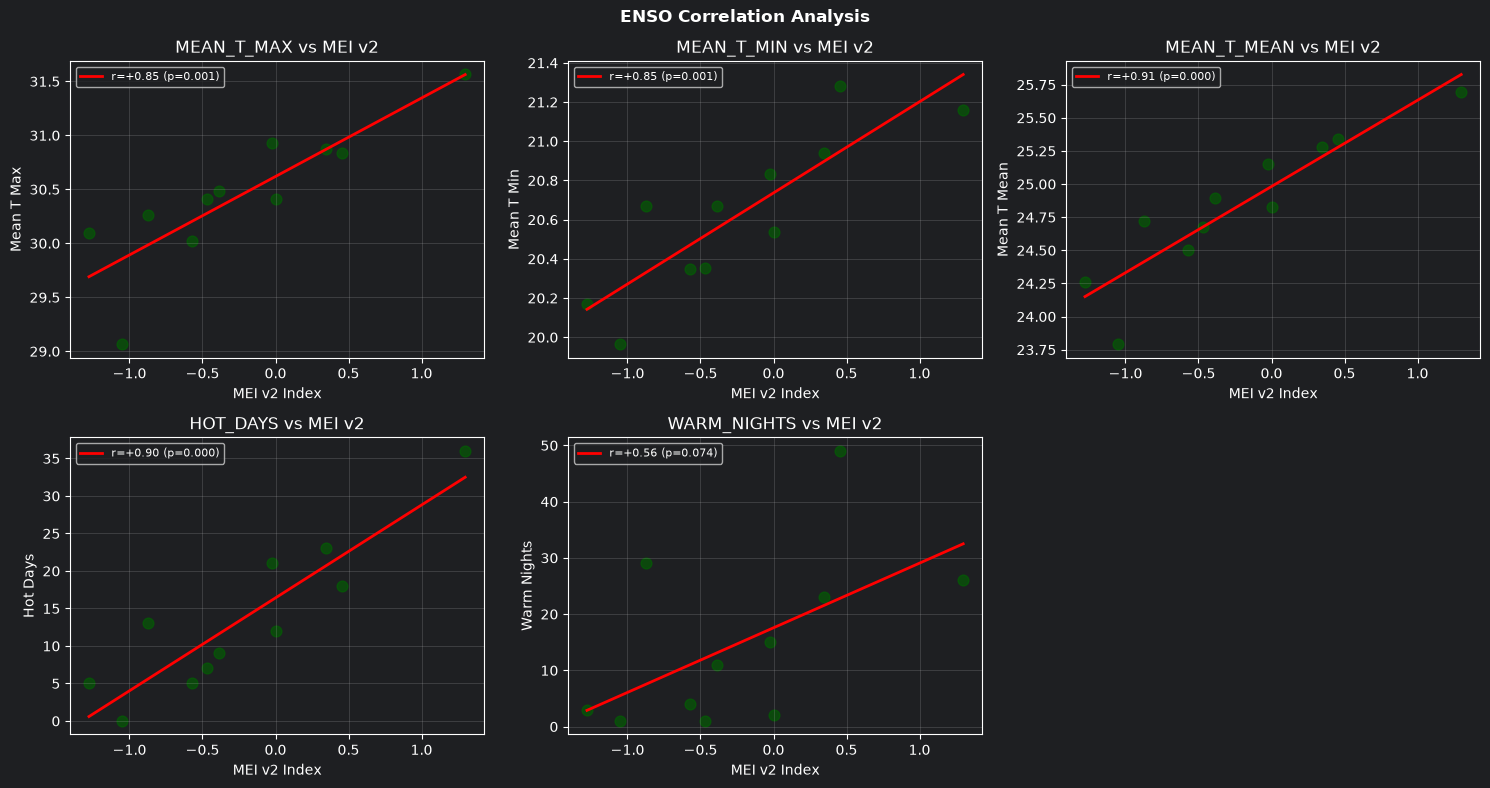

In [22]:
# ENSO scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, var in enumerate(enso_metrics):
    mask = df_annual[var].notna() & df_annual['enso_index'].notna()
    x = df_annual.loc[mask, 'enso_index'].values
    y = df_annual.loc[mask, var].values
    
    ax = axes[idx]
    ax.scatter(x, y, s=60, alpha=0.6, color='darkgreen')
    
    if len(x) >= 3:
        r, p = stats.pearsonr(x, y)
        # Fit line
        z = np.polyfit(x, y, 1)
        p_fit = np.poly1d(z)
        x_line = np.array([x.min(), x.max()])
        ax.plot(x_line, p_fit(x_line), 'r-', linewidth=2, label=f'r={r:+.2f} (p={p:.3f})')
        ax.legend(fontsize=8)
    
    ax.set_xlabel(f'{enso_index_used} Index')
    ax.set_ylabel(var.replace('_', ' ').title())
    ax.set_title(f'{var.upper()} vs {enso_index_used}')
    ax.grid(True, alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])
plt.suptitle(f'ENSO Correlation Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:**

**Interpretation: ENSO-Detrended Trend**\n\nComparison of raw trends (Section 4–5) vs. ENSO-detrended residual trends above:\n\n- If residual slopes are similar to raw slopes: the temperature trend is a background climate signal, **not an ENSO artifact**.\n- If residual slopes are much weaker or reverse sign: the apparent trend was driven by the specific ENSO sequence in this sample period."



ENSO-DETRENDED TREND ANALYSIS

Raw vs. ENSO-Detrended Trend Comparison:
   Variable Raw Slope  Raw p Residual Slope Residual p
 MEAN_T_MAX    +0.766 0.0866         -0.021     1.0000
 MEAN_T_MIN    +0.544 0.1646         +0.085     0.7612
MEAN_T_MEAN    +0.684 0.1210         -0.031     1.0000
   HOT_DAYS   +15.000 0.1183         -0.886     0.7612
WARM_NIGHTS   +11.667 0.5322         +3.739     0.6481

Generating visualization...


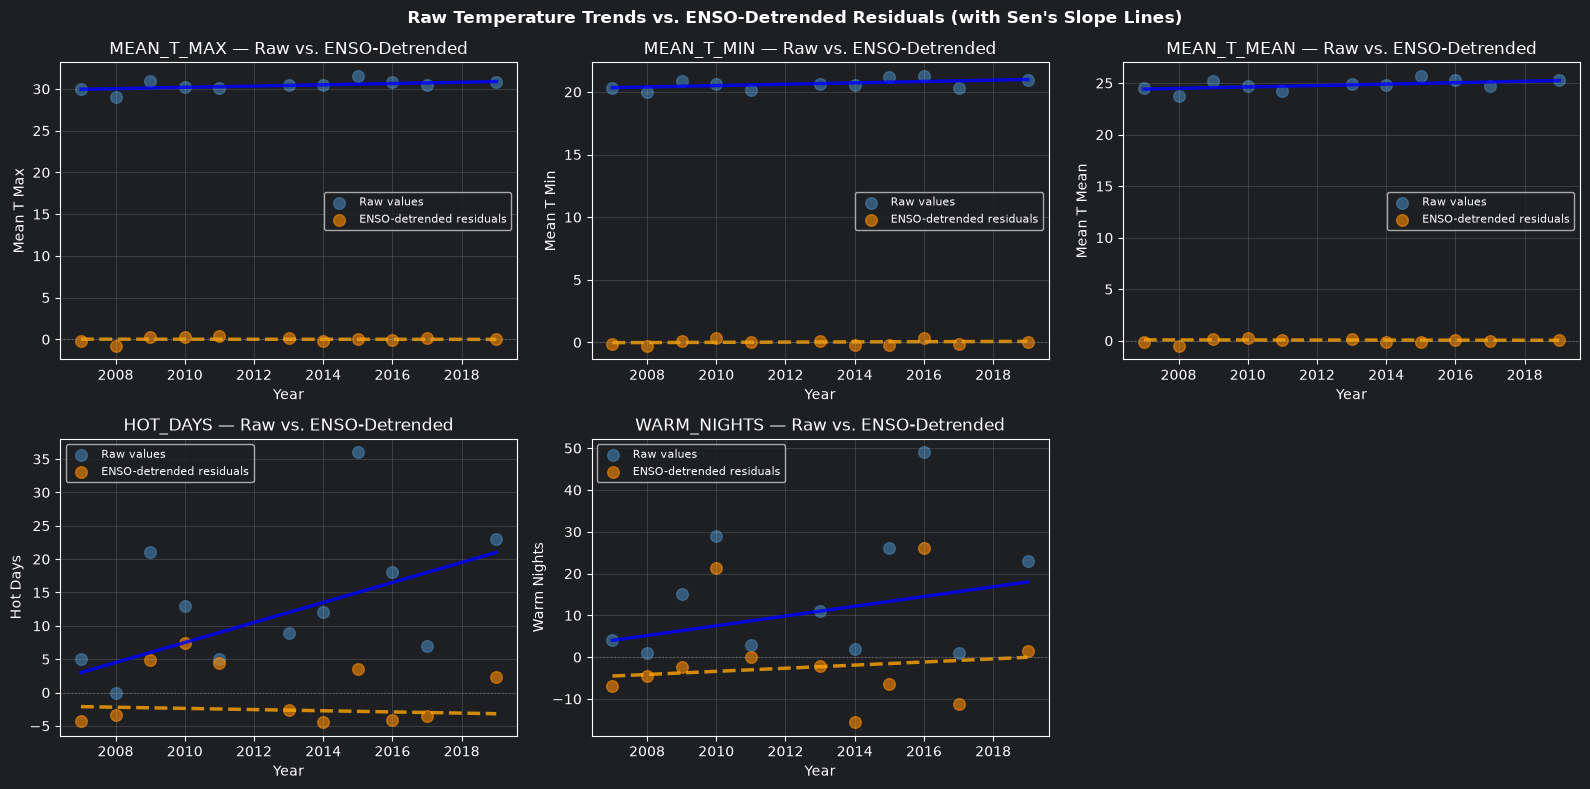

✓ Section 7.5 complete


In [23]:
# Section 7.5: ENSO-Detrended Trend Analysis (comprehensive)
print(f"\n{'='*80}")
print("ENSO-DETRENDED TREND ANALYSIS")
print(f"{'='*80}\n")

# Store raw trends for comparison
raw_trends_dict = {}
for idx, var in enumerate(['mean_t_max', 'mean_t_min', 'mean_t_mean', 'hot_days', 'warm_nights']):
    years = df_annual.index.values
    values = df_annual[var].values
    tau, p_value = stats.kendalltau(years, values)
    slope, intercept, low_ci, high_ci = theilslopes(values, years, alpha=0.05)
    slope_decade = slope * 10
    raw_trends_dict[var] = {'slope': slope_decade, 'p_value': p_value}

# Compute ENSO-detrended trends
detrended_trends = []

for var in enso_metrics:
    years = df_annual.index.values
    values = df_annual[var].values
    enso_vals = df_annual['enso_index'].values
    
    # Regress metric on ENSO to get residuals
    mask = pd.Series(True, index=df_annual.index)
    mask = mask & df_annual[var].notna() & df_annual['enso_index'].notna()
    
    if mask.sum() >= 3:
        x_enso = df_annual.loc[mask, 'enso_index'].values
        y_vals = df_annual.loc[mask, var].values
        
        # Linear fit: metric = a * ENSO + b
        z_enso = np.polyfit(x_enso, y_vals, 1)
        p_enso = np.poly1d(z_enso)
        
        # Compute residuals
        residuals = y_vals - p_enso(x_enso)
        years_masked = df_annual.loc[mask].index.values
        
        # Trend test on residuals
        tau_res, p_res = stats.kendalltau(years_masked, residuals)
        slope_res, intercept_res, low_ci_res, high_ci_res = theilslopes(residuals, years_masked, alpha=0.05)
        
        # Convert to per-decade
        slope_res_decade = slope_res * 10
        low_ci_res_decade = low_ci_res * 10
        high_ci_res_decade = high_ci_res * 10
        
        raw_slope = raw_trends_dict[var]['slope']
        raw_p = raw_trends_dict[var]['p_value']
        
        detrended_trends.append({
            'Variable': var.upper(),
            'Raw Slope': f"{raw_slope:+.3f}",
            'Raw p': f"{raw_p:.4f}",
            'Residual Slope': f"{slope_res_decade:+.3f}",
            'Residual p': f"{p_res:.4f}",
            'Slope_numeric': slope_res_decade,
            'P_numeric': p_res,
        })

df_detrended = pd.DataFrame(detrended_trends)
print("Raw vs. ENSO-Detrended Trend Comparison:")
print(df_detrended[['Variable', 'Raw Slope', 'Raw p', 'Residual Slope', 'Residual p']].to_string(index=False))

# Visualization: raw vs. ENSO-detrended trends
print(f"\nGenerating visualization...")
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(enso_metrics):
    ax = axes[idx]
    years = df_annual.index.values
    values = df_annual[var].values
    
    # Plot raw values
    ax.scatter(years, values, s=70, alpha=0.6, color='steelblue', label='Raw values')
    
    # Fit raw trend line
    tau, p_value = stats.kendalltau(years, values)
    slope, intercept, low_ci, high_ci = theilslopes(values, years, alpha=0.05)
    fit_raw = intercept + slope * years
    ax.plot(years, fit_raw, 'b-', linewidth=2.5, alpha=0.8)
    
    # Compute and plot residuals
    mask = df_annual[var].notna() & df_annual['enso_index'].notna()
    if mask.sum() >= 3:
        x_enso = df_annual.loc[mask, 'enso_index'].values
        y_vals = df_annual.loc[mask, var].values
        z_enso = np.polyfit(x_enso, y_vals, 1)
        p_enso = np.poly1d(z_enso)
        residuals = y_vals - p_enso(x_enso)
        years_masked = df_annual.loc[mask].index.values
        
        # Plot residuals
        ax.scatter(years_masked, residuals, s=70, alpha=0.6, color='darkorange', label='ENSO-detrended residuals')
        
        # Fit residual trend line
        tau_res, p_res = stats.kendalltau(years_masked, residuals)
        slope_res, intercept_res, low_ci_res, high_ci_res = theilslopes(residuals, years_masked, alpha=0.05)
        fit_res = intercept_res + slope_res * years_masked
        ax.plot(years_masked, fit_res, 'orange', linewidth=2.5, alpha=0.8, linestyle='--')
    
    ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_xlabel('Year')
    ax.set_ylabel(var.replace('_', ' ').title())
    ax.set_title(f'{var.upper()} — Raw vs. ENSO-Detrended')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

fig.delaxes(axes[5])
plt.suptitle('Raw Temperature Trends vs. ENSO-Detrended Residuals (with Sen\'s Slope Lines)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"✓ Section 7.5 complete")

## Section 7.5 — ENSO-Detrended Trend Analysis

## Section 8 — Combined Interpretation